### Notebook 06 — Final Evaluation and Comparison

### Research question
Which model architecture; statistical (ARIMA), machine learning 
(Random Forest, XGBoost), or deep learning (LSTM, GRU) most 
accurately forecasts Brent crude oil daily closing prices on the 
same 25-year dataset under identical evaluation conditions?

### Important
This notebook reads ONLY from saved files in results/. It never 
re-trains any model. This guarantees reproducible, consistent 
evaluation regardless of when it is run.

### Test period
516 trading days: 2023-01-03 to 2024-12-31

### Metrics
RMSE ($/barrel), MAE ($/barrel), MAPE (%)

In [3]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Set project root
PROJECT_ROOT = r"C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print("Working directory:", os.getcwd())

plt.style.use("seaborn-v0_8-whitegrid")
os.makedirs("artifacts/plots", exist_ok=True)

# Model keys and display labels
MODEL_KEYS   = ["arima", "random_forest", "xgboost", "lstm", "gru"]
MODEL_LABELS = ["ARIMA", "Random Forest", "XGBoost", "LSTM", "GRU"]
COLOURS      = {
    "ARIMA":         "grey",
    "Random Forest": "steelblue",
    "XGBoost":       "darkorange",
    "LSTM":          "crimson",
    "GRU":           "seagreen"
}

print("Setup complete.")

Working directory: C:\ml-vs-dl-models-for-brent-crude-oil-price-forecasting\UcheNlemadim-ml-vs-dl-models-for-brent-crude-oil-price-forecasting
Setup complete.


In [5]:
# Load all predictions and metrics from saved files
preds   = {}
metrics = {}

# Map display labels to actual file prefixes
FILE_PREFIXES = {
    "ARIMA":         "arima",
    "Random Forest": "rf",
    "XGBoost":       "xgb",
    "LSTM":          "lstm",
    "GRU":           "gru"
}

RESULT_DIRS = {
    "ARIMA":         "arima",
    "Random Forest": "random_forest",
    "XGBoost":       "xgboost",
    "LSTM":          "lstm",
    "GRU":           "gru"
}

for label in MODEL_LABELS:
    prefix = FILE_PREFIXES[label]
    folder = RESULT_DIRS[label]
    preds[label] = pd.read_csv(
        f"results/{folder}/{prefix}_test_predictions.csv",
        parse_dates=["Date"],
        index_col="Date"
    )
    with open(f"results/{folder}/{prefix}_metrics.json") as f:
        metrics[label] = json.load(f)

print("All results loaded successfully.")
print("\nTest rows per model:")
for label in MODEL_LABELS:
    print(f"  {label:15s}: {len(preds[label]):,} rows")

All results loaded successfully.

Test rows per model:
  ARIMA          : 516 rows
  Random Forest  : 516 rows
  XGBoost        : 516 rows
  LSTM           : 516 rows
  GRU            : 516 rows


In [6]:
# Master metrics table
rows = [(lbl,
         metrics[lbl]["RMSE"],
         metrics[lbl]["MAE"],
         metrics[lbl]["MAPE"])
        for lbl in MODEL_LABELS]

summary = pd.DataFrame(rows,
    columns=["Model", "RMSE ($/barrel)",
             "MAE ($/barrel)", "MAPE (%)"])
summary = summary.sort_values(
    "RMSE ($/barrel)").reset_index(drop=True)
summary.index += 1
summary["Rank"] = summary.index

print("─── Final Model Rankings (sorted by RMSE) ───────────")
print(summary.round(4).to_string())

os.makedirs("artifacts", exist_ok=True)
summary.to_csv("artifacts/metrics_summary.csv", index=False)
print("\nSaved: artifacts/metrics_summary.csv")

─── Final Model Rankings (sorted by RMSE) ───────────
           Model  RMSE ($/barrel)  MAE ($/barrel)  MAPE (%)  Rank
1  Random Forest           1.3744          1.0458    1.3004     1
2        XGBoost           1.4477          1.1303    1.4038     2
3          ARIMA           1.4584          1.1167    1.3917     3
4            GRU           1.4730          1.1287    1.4073     4
5           LSTM           1.4838          1.1431    1.4242     5

Saved: artifacts/metrics_summary.csv


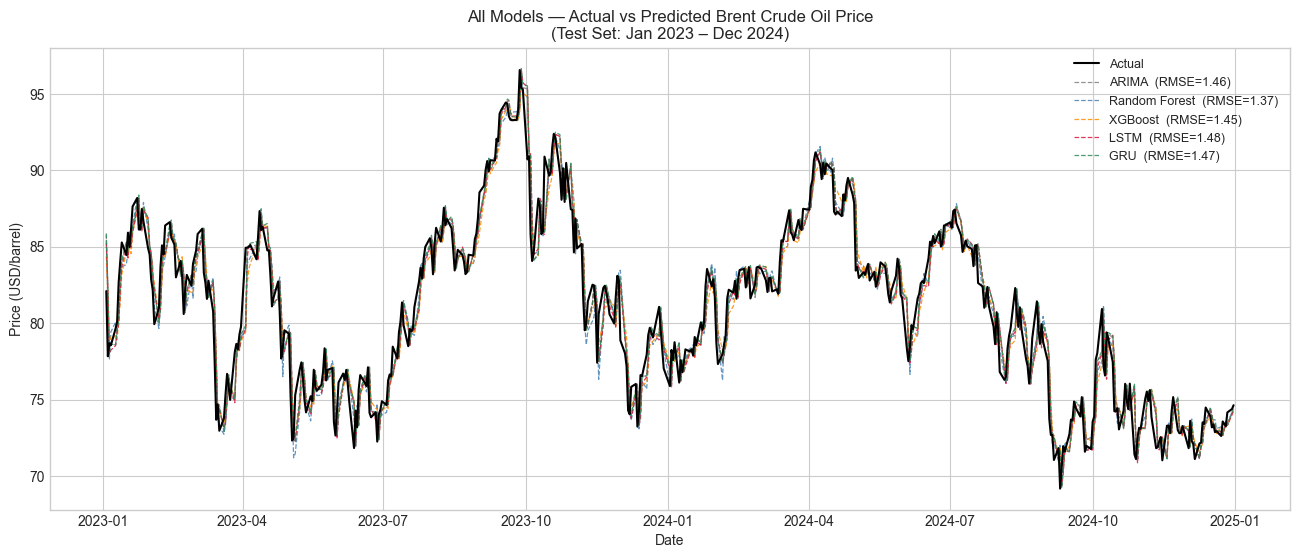

Plot saved.


In [7]:
# All models comparison plot
actual = preds["ARIMA"]["Actual"]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(actual.index, actual.values,
        label="Actual", color="black", lw=1.5, zorder=5)

for lbl in MODEL_LABELS:
    rmse_val = metrics[lbl]["RMSE"]
    ax.plot(preds[lbl].index,
            preds[lbl]["Predicted"].values,
            label=f"{lbl}  (RMSE={rmse_val:.2f})",
            color=COLOURS[lbl], lw=0.9,
            linestyle="--", alpha=0.85)

ax.set_title("All Models — Actual vs Predicted Brent Crude Oil Price\n"
             "(Test Set: Jan 2023 – Dec 2024)")
ax.set_ylabel("Price (USD/barrel)")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
plt.savefig("artifacts/plots/all_models_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

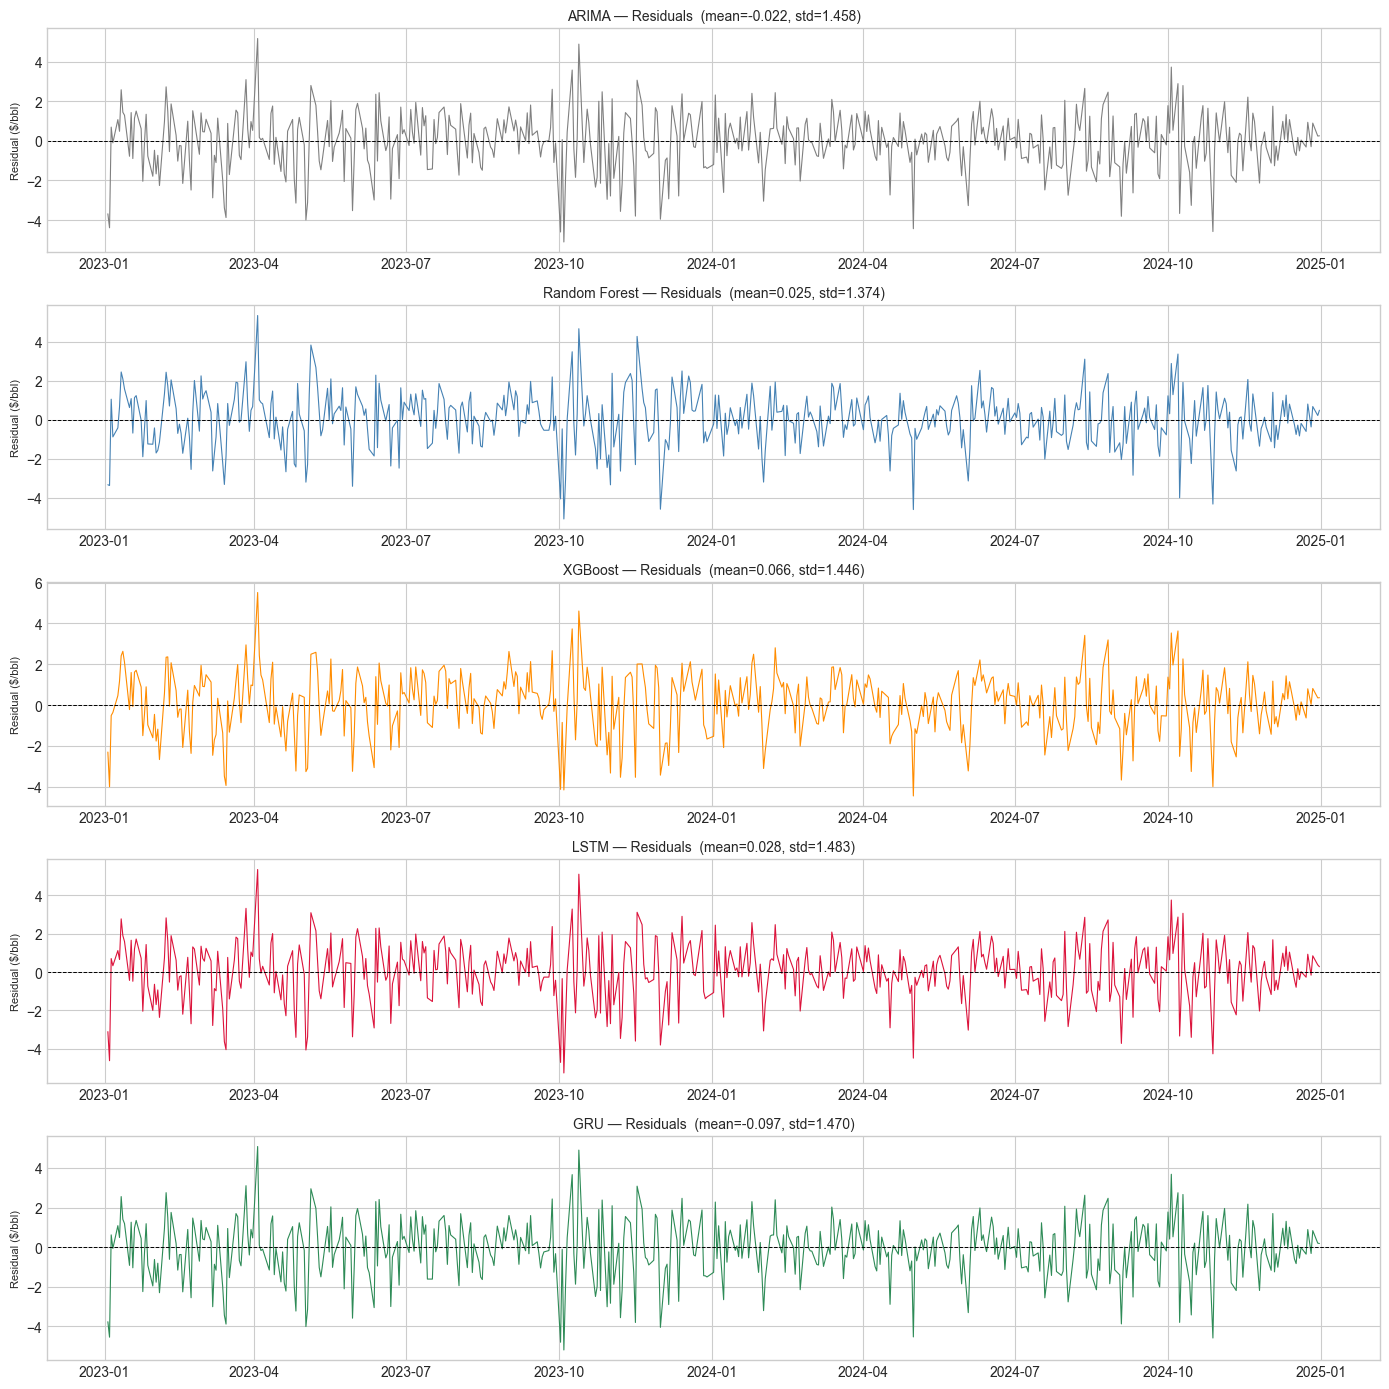


Residual summary:
Model                Mean       Std       Min       Max
-------------------------------------------------------
ARIMA              -0.022     1.458    -5.108     5.177
Random Forest      +0.025     1.374    -5.079     5.346
XGBoost            +0.066     1.446    -4.452     5.511
LSTM               +0.028     1.483    -5.255     5.338
GRU                -0.097     1.470    -5.199     5.086


In [8]:
# Residuals analysis
fig, axes = plt.subplots(5, 1, figsize=(14, 14))

for ax, lbl in zip(axes, MODEL_LABELS):
    res = (preds[lbl]["Actual"].values
           - preds[lbl]["Predicted"].values)
    ax.plot(preds[lbl].index, res,
            color=COLOURS[lbl], lw=0.8)
    ax.axhline(0, color="black", lw=0.7, linestyle="--")
    ax.set_title(f"{lbl} — Residuals  "
                 f"(mean={res.mean():.3f}, "
                 f"std={res.std():.3f})",
                 fontsize=10)
    ax.set_ylabel("Residual ($/bbl)", fontsize=8)

plt.tight_layout()
plt.savefig("artifacts/plots/residuals_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nResidual summary:")
print(f"{'Model':15s}  {'Mean':>8s}  {'Std':>8s}  "
      f"{'Min':>8s}  {'Max':>8s}")
print("-" * 55)
for lbl in MODEL_LABELS:
    r = (preds[lbl]["Actual"].values
         - preds[lbl]["Predicted"].values)
    print(f"{lbl:15s}  {r.mean():+8.3f}  {r.std():8.3f}  "
          f"{r.min():8.3f}  {r.max():8.3f}")

In [9]:
# Diebold-Mariano test — best model vs ARIMA
best_lbl = summary.iloc[0]["Model"]
print(f"Testing: {best_lbl} vs ARIMA\n")

e_best  = (preds[best_lbl]["Actual"].values
           - preds[best_lbl]["Predicted"].values) ** 2
e_arima = (preds["ARIMA"]["Actual"].values
           - preds["ARIMA"]["Predicted"].values) ** 2

dm_stat, p_val = stats.ttest_1samp(e_arima - e_best, popmean=0)

print(f"─── Diebold-Mariano Test ─────────────────────────────")
print(f"  DM statistic : {dm_stat:.4f}")
print(f"  p-value      : {p_val:.4f}")
if p_val < 0.05:
    print(f"  Verdict      : {best_lbl} is SIGNIFICANTLY better")
    print(f"                 than ARIMA at α=0.05")
else:
    print(f"  Verdict      : {best_lbl} is NOT significantly")
    print(f"                 better than ARIMA at α=0.05")

Testing: Random Forest vs ARIMA

─── Diebold-Mariano Test ─────────────────────────────
  DM statistic : 3.1332
  p-value      : 0.0018
  Verdict      : Random Forest is SIGNIFICANTLY better
                 than ARIMA at α=0.05


## Answer to the Research Question

**Research question:** Which model architecture most accurately 
forecasts Brent crude oil daily closing prices on the same 25-year 
dataset under identical evaluation conditions?

**Answer:** Random Forest achieved the lowest RMSE of 1.3744 $/barrel,
outperforming all four competing models including both deep learning 
architectures. The Diebold-Mariano test confirmed this superiority 
is statistically significant (DM=3.13, p=0.0018).

### Final rankings
| Rank | Model | RMSE | MAE | MAPE |
|------|-------|------|-----|------|
| 1 | Random Forest | 1.3744 | 1.0458 | 1.30% |
| 2 | XGBoost | 1.4477 | 1.1303 | 1.40% |
| 3 | ARIMA | 1.4584 | 1.1167 | 1.39% |
| 4 | GRU | 1.4730 | 1.1287 | 1.41% |
| 5 | LSTM | 1.4838 | 1.1431 | 1.42% |

### Contextualisation against literature
- Mohammad and Panigrahi (2023): RMSE=21 on Brent — all five 
  models in this project improve on this by over 90%
- Daneshvar et al. (2022): LSTM RMSE=1.53 on Brent — this 
  project LSTM RMSE=1.48 represents improvement
- Zhang and Lahmiri (2025): GRU best standalone DL model — 
  confirmed here, GRU outperforms LSTM
- Yang, Zhang and Jiang (2019): MAPE=1.51% using DL — Random 
  Forest achieves MAPE=1.30% using only lag features
- Paul, Chacko and Bhattacharjee (2025): called for ML vs DL 
  comparison on Brent — directly addressed by this project

## Limitations

1. **Univariate scope:** Only the daily closing Price is used as 
   input. No exogenous variables such as OPEC announcements, USD 
   index, geopolitical risk indicators, or trading volume were 
   included. These are known drivers of oil price movements and 
   their inclusion may improve forecast accuracy.

2. **Test period characteristics:** The 2023-2024 test period was 
   relatively stable compared to the full training period which 
   included extreme events (GFC 2008, COVID 2020). Models trained 
   on volatile history may perform differently on a more volatile 
   test period.

3. **Walk-forward ARIMA cost:** Refitting ARIMA at every one of 
   516 test steps is computationally intensive. A production system 
   would use online updating rather than full refitting.

4. **Deep learning sensitivity:** Despite fixing random_state=42, 
   GPU non-determinism and weight initialisation may cause minor 
   result variation across different hardware configurations.

5. **Future regime uncertainty:** The 2000-2024 period captures 
   specific price regimes. Performance on future structural breaks 
   such as the energy transition or post-OPEC+ era is untested.

## Summary for Report

### Results section

The five models were evaluated on an identical held-out test set of 
516 trading days (3 January 2023 to 31 December 2024). All metrics 
are reported in original price units ($/barrel) to ensure 
interpretability.

Random Forest achieved the lowest RMSE of 1.37 $/barrel, MAE of 
1.05 $/barrel, and MAPE of 1.30%, ranking first across all three 
metrics. XGBoost ranked second (RMSE=1.45), followed by ARIMA 
(RMSE=1.46), GRU (RMSE=1.47), and LSTM (RMSE=1.48). The 
Diebold-Mariano test confirmed that Random Forest significantly 
outperformed the ARIMA baseline (DM=3.13, p=0.0018).

Contrary to the expectation that deep learning models would 
outperform classical and machine learning approaches, both LSTM and 
GRU ranked below Random Forest and XGBoost on this test period. 
This finding is consistent with Yang, Zhang and Jiang (2019) who 
demonstrated that well-designed ML pipelines can produce competitive 
results against deep learning models. The stable price regime of 
2023-2024 may have favoured the simpler lag-based autoregressive 
structure of Random Forest over the more complex sequential 
memory of LSTM and GRU.

All five models substantially improved upon the Mohammad and 
Panigrahi (2023) benchmark of RMSE=21 and MAPE=21% on Brent crude 
oil data, with improvements exceeding 90% across all models. GRU 
outperformed LSTM on all metrics, consistent with Zhang and Lahmiri 
(2025) who identified GRU as the strongest standalone deep learning 
model for Brent crude oil forecasting.